C:\Users\Gaurang\AppData\Local\Temp\ipykernel_25244\2320084481.py:23: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'])




Params → units=32, lr=0.001 , batch_size=32, epochs=30

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
GRU → MSE: 0.000304, R2: 0.0138
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Seq2Seq → MSE: 0.000117, R2: 0.6193
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Seq2Seq+Attn → MSE: 0.000106, R2: 0.6545


Params → units=32, lr=0.0005 , batch_size=32, epochs=30

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
GRU → MSE: 0.000276, R2: 0.1039
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Seq2Seq → MSE: 0.000275, R2: 0.1084
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Seq2Seq+Attn → MSE: 0.000134, R2: 0.5641


Params → units=32, lr=0.001 , batch_size=32, epochs=50

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
GRU → MSE: 0.000219, R2: 0.2888
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Seq2Seq → MSE: 0.000098, R2: 0.6820
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Seq2Seq+Attn → MSE: 0.000127, R2: 0.5877


Params → units=32, lr=0.0005 , batch_size=32, epochs=50

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
GRU → MSE: 0.000253, R2: 0.1782
21/21 ━

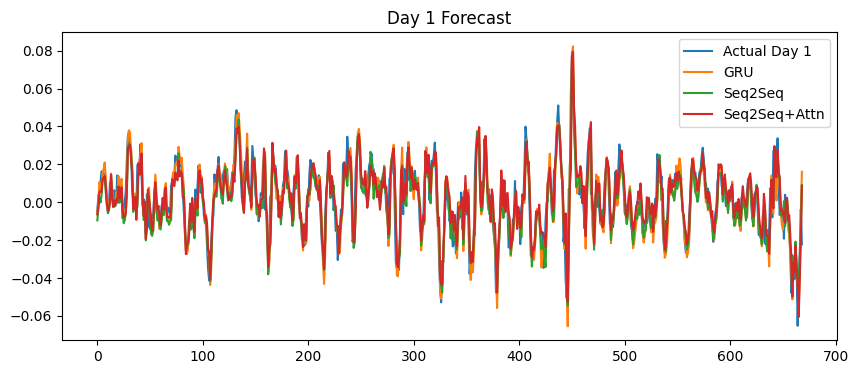

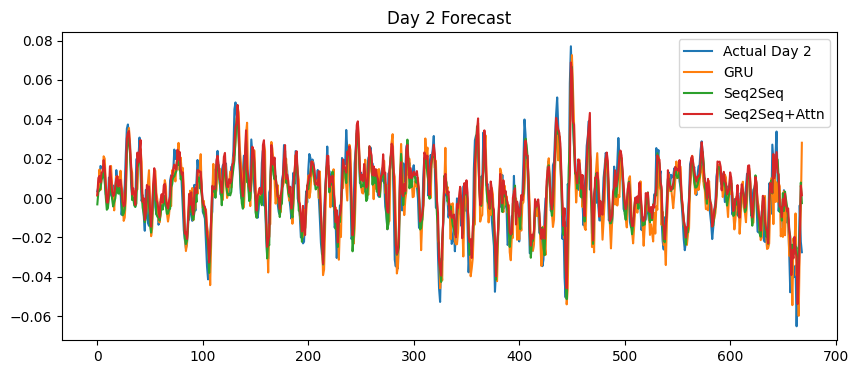

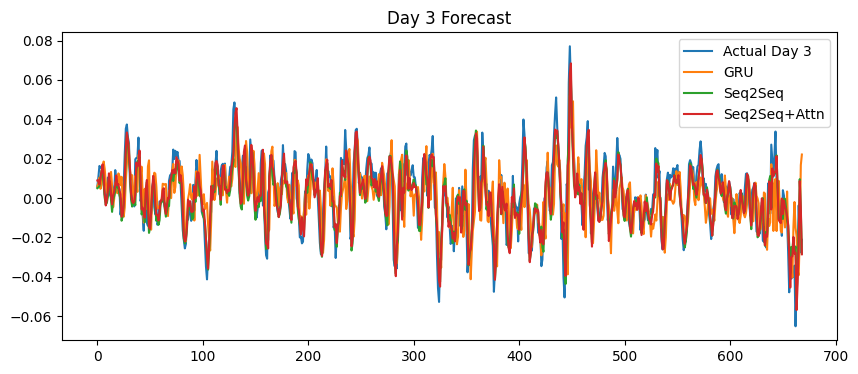

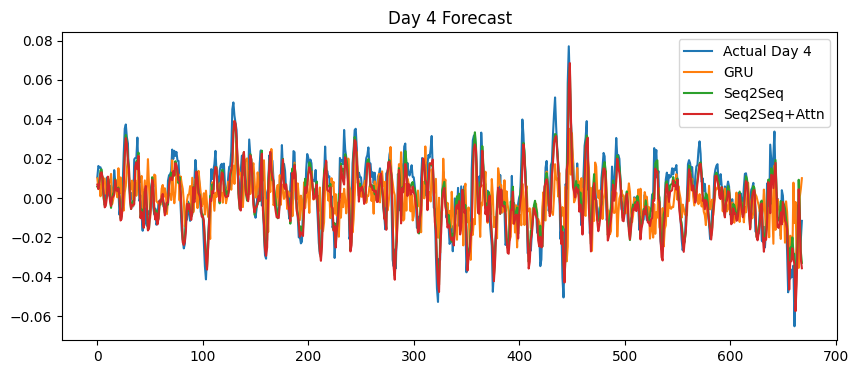

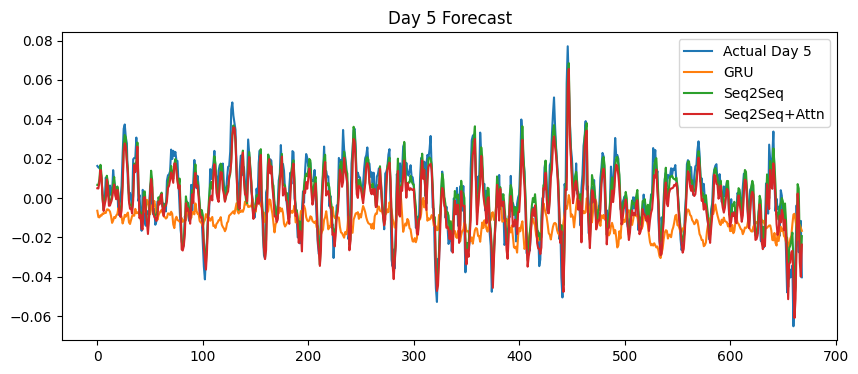

In [ ]:
# =========================
# IMPORTS
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import zscore

import tensorflow as tf
from tensorflow.keras.layers import Input, GRU, Dense, Attention, Concatenate, TimeDistributed
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dot, Activation

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("D:\\COLLEGE\\DAIICT\\Semester-2\\Applied Forecasting\\re_implemented_project\\data\\nifty50_with_sector_returns_yfinance1.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df.set_index('date', inplace=True)

df = df[~df.index.duplicated()]
df = df.ffill().bfill()
df = df[(np.abs(zscore(df)) < 3).all(axis=1)]

# =========================
# FEATURE ENGINEERING
# =========================
df['return'] = df['close'].pct_change(5)
df = df.dropna()

for lag in range(1, 6):
    df[f'return_lag_{lag}'] = df['return'].shift(lag)

df['rolling_mean_5'] = df['return'].rolling(5).mean()
df['rolling_std_5'] = df['return'].rolling(5).std()

df['momentum'] = df['close'] - df['close'].shift(5)

delta = df['close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = -delta.clip(upper=0).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain/loss))

df['EMA_10'] = df['close'].ewm(span=10).mean()
df['volatility'] = df['return'].rolling(10).std()

df['bank_trend'] = df['nifty_bank_ret'].rolling(5).mean()
df['it_trend'] = df['nifty_it_ret'].rolling(5).mean()

df = df.dropna()

# =========================
# DATA PREP
# =========================
features = df.columns.tolist()
features.remove('return')

X = df[features]
y = df['return']

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))

def create_dataset(X, y, n_steps=20, horizon=5):
    Xs, ys = [], []
    for i in range(len(X) - n_steps - horizon):
        Xs.append(X[i:i+n_steps])
        ys.append(y[i+n_steps:i+n_steps+horizon])
    return np.array(Xs), np.array(ys)

n_steps = 20
horizon = 5

X_seq, y_seq = create_dataset(X_scaled, y_scaled, n_steps, horizon)

split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

# =========================
# TEACHER FORCING
# =========================
def create_decoder_input(y):
    decoder_input = np.zeros_like(y)
    decoder_input[:, 1:, :] = y[:, :-1, :]
    return decoder_input

y_train = y_train.reshape(-1, horizon, 1)
y_test = y_test.reshape(-1, horizon, 1)

decoder_input_train = create_decoder_input(y_train)
decoder_input_test = create_decoder_input(y_test)

# =========================
# INVERSE TARGET
# =========================
y_test_inv = scaler_y.inverse_transform(
    y_test.reshape(-1,1)
).reshape(-1, horizon)

# =========================
# MODELS
# =========================

def build_attention_gru(n_steps, n_features, horizon, units=64, lr=0.001):
    inputs = Input(shape=(n_steps, n_features))
    x = GRU(units, return_sequences=True)(inputs)
    attention = Attention()([x, x])
    x = Concatenate()([x, attention])
    x = GRU(units)(x)
    x = Dense(32, activation='relu')(x)
    outputs = Dense(horizon)(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse')
    return model

def build_seq2seq_gru(n_steps, n_features, horizon, units=64, lr=0.001):
    encoder_inputs = Input(shape=(n_steps, n_features))
    _, state_h = GRU(units, return_state=True)(encoder_inputs)

    decoder_inputs = Input(shape=(horizon, 1))
    decoder_outputs = GRU(units, return_sequences=True)(decoder_inputs, initial_state=state_h)

    outputs = TimeDistributed(Dense(1))(decoder_outputs)

    model = Model([encoder_inputs, decoder_inputs], outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse')
    return model

def build_seq2seq_attention(n_steps, n_features, horizon, units=64, lr=0.001):

    encoder_inputs = Input(shape=(n_steps, n_features))
    encoder_outputs, state_h = GRU(units, return_sequences=True, return_state=True)(encoder_inputs)

    decoder_inputs = Input(shape=(horizon, 1))
    decoder_outputs = GRU(units, return_sequences=True)(decoder_inputs, initial_state=state_h)

    score = Dot(axes=[2, 2])([decoder_outputs, encoder_outputs])
    attention_weights = Activation('softmax')(score)
    context = Dot(axes=[2,1])([attention_weights, encoder_outputs])

    decoder_combined = Concatenate()([context, decoder_outputs])
    outputs = TimeDistributed(Dense(1))(decoder_combined)

    model = Model([encoder_inputs, decoder_inputs], outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse')
    return model

# =========================
# 🔥 COMBINED GRID SEARCH
# =========================

# BEST PARAMS: (64, 32, 50, 0.001)
param_grid = {
    'units': [64],
    'batch_size': [32],
    'epochs': [50],
    'lr': [0.001]
}

best_mse_attn = float('inf')
best_models = {}
best_params = None

for units, batch_size, epochs, lr in itertools.product(
    param_grid['units'],
    param_grid['batch_size'],
    param_grid['epochs'],
    param_grid['lr']
):
    print("\n")
    print(f"Params → units={units}, lr={lr} , batch_size={batch_size}, epochs={epochs}")
    print("")

    # GRU
    model_gru = build_attention_gru(n_steps, X_train.shape[2], horizon, units, lr)
    model_gru.fit(X_train, y_train.reshape(-1, horizon), epochs=epochs, batch_size=batch_size, verbose=0)

    y_pred_gru = model_gru.predict(X_test).reshape(-1, horizon, 1)
    y_pred_gru_inv = scaler_y.inverse_transform(y_pred_gru.reshape(-1,1)).reshape(-1, horizon)

    mse_gru = mean_squared_error(y_test_inv, y_pred_gru_inv)
    r2_gru = r2_score(y_test_inv, y_pred_gru_inv)

    print(f"GRU → MSE: {mse_gru:.6f}, R2: {r2_gru:.4f}")

    # Seq2Seq
    model_seq = build_seq2seq_gru(n_steps, X_train.shape[2], horizon, units, lr)
    model_seq.fit([X_train, decoder_input_train], y_train, epochs=epochs, batch_size=batch_size, verbose=0)

    y_pred_seq = model_seq.predict([X_test, decoder_input_test])
    y_pred_seq_inv = scaler_y.inverse_transform(y_pred_seq.reshape(-1,1)).reshape(-1, horizon)

    mse_seq = mean_squared_error(y_test_inv, y_pred_seq_inv)
    r2_seq = r2_score(y_test_inv, y_pred_seq_inv)

    print(f"Seq2Seq → MSE: {mse_seq:.6f}, R2: {r2_seq:.4f}")

    # Seq2Seq + Attention
    model_attn = build_seq2seq_attention(n_steps, X_train.shape[2], horizon, units, lr)
    model_attn.fit([X_train, decoder_input_train], y_train, epochs=epochs, batch_size=batch_size, verbose=0)

    y_pred_attn = model_attn.predict([X_test, decoder_input_test])
    y_pred_attn_inv = scaler_y.inverse_transform(y_pred_attn.reshape(-1,1)).reshape(-1, horizon)

    mse_attn = mean_squared_error(y_test_inv, y_pred_attn_inv)
    r2_attn = r2_score(y_test_inv, y_pred_attn_inv)

    print(f"Seq2Seq+Attn → MSE: {mse_attn:.6f}, R2: {r2_attn:.4f}")

    # 🔥 Select best ONLY based on attention
    if mse_attn < best_mse_attn:
        best_mse_attn = mse_attn
        best_params = (units, batch_size, epochs, lr)

        best_models = {
            "gru": model_gru,
            "seq": model_seq,
            "attn": model_attn
        }

print("\n🔥 BEST PARAMS:", best_params)
print("🔥 BEST ATTENTION MSE:", best_mse_attn)

# =========================
# FINAL PREDICTIONS
# =========================

best_gru = best_models["gru"]
best_seq = best_models["seq"]
best_attn = best_models["attn"]

y_pred_gru = best_gru.predict(X_test).reshape(-1, horizon, 1)
y_pred_seq = best_seq.predict([X_test, decoder_input_test])
y_pred_attn = best_attn.predict([X_test, decoder_input_test])

y_pred_gru_inv = scaler_y.inverse_transform(y_pred_gru.reshape(-1,1)).reshape(-1, horizon)
y_pred_seq_inv = scaler_y.inverse_transform(y_pred_seq.reshape(-1,1)).reshape(-1, horizon)
y_pred_attn_inv = scaler_y.inverse_transform(y_pred_attn.reshape(-1,1)).reshape(-1, horizon)

# =========================
# METRICS
# =========================

def evaluate(y_true, y_pred, name):
    print(name)
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:", r2_score(y_true, y_pred))
    print("-"*30)

evaluate(y_test_inv, y_pred_gru_inv, "GRU")
evaluate(y_test_inv, y_pred_seq_inv, "Seq2Seq")
evaluate(y_test_inv, y_pred_attn_inv, "Seq2Seq+Attention")

# =========================
# VISUALIZATION
# =========================

for i in range(horizon):
    plt.figure(figsize=(10,4))
    plt.plot(y_test_inv[:, i], label=f"Actual Day {i+1}")
    plt.plot(y_pred_gru_inv[:, i], label="GRU")
    plt.plot(y_pred_seq_inv[:, i], label="Seq2Seq")
    plt.plot(y_pred_attn_inv[:, i], label="Seq2Seq+Attn")
    plt.legend()
    plt.title(f"Day {i+1} Forecast")
    plt.show()

In [ ]:
Print("MSE: 8.586295186567162e-05")